In [1]:
import sys

sys.path.append("..")

import torch
import matplotlib.pyplot as plt
import numpy as np

from src.paths import Paths
from src.utils import (
    get_device,
    tensor_to_img,
    plot_image,
    initialize_resnet18,
    load_model_weights,
)
from src.data_manager import DataManager
from src.perturbations import Perturbations
from src import config
from src.explainers import IGExplainer, OcclusionExplainer
from src.xai_experiment import XAIExperiment

## Konfiguracja ogólna

In [2]:
dataset_name = "mnist"
epsilon = 0.5

device = get_device()
empty_model = initialize_resnet18(pretrained=False)

paths = Paths()

model = load_model_weights(empty_model, paths.MNIST_MODEL, device)

data_manager = DataManager(paths.DATA_DIR)

test_data = data_manager.get_test_dataset(dataset_name=dataset_name, download=False)
class_names = data_manager.get_class_names(dataset_name=dataset_name)

perturbations = Perturbations(model=model, device=device)

## Wybór badanych przykładów

In [3]:
max_examples_per_class = 10

clean_examples = {class_id: [] for class_id in range(len(class_names))}

for image, label in test_data:
    if len(clean_examples[label]) >= max_examples_per_class:
        continue

    tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        pred = output.argmax(dim=1).item()

    if pred == label:
        clean_examples[label].append(image)

    if all(
        len(clean_examples[class_id]) >= max_examples_per_class
        for class_id in clean_examples
    ):
        break

clean_examples_vis = {
    class_id: clean_examples[class_id][0] for class_id in clean_examples
}

## Konfiguracja IG

In [4]:
ig_explainer = IGExplainer(model=model, device=device, config=config.IGConfig())
ig_experiment = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples,
    explainer=ig_explainer,
    perturbations=perturbations,
)
ig_experiment_vis = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples_vis,
    explainer=ig_explainer,
    perturbations=perturbations,
)

ig_classes = ig_experiment_vis.selected_classes

all_ig_attrs = []
for class_id in ig_classes:
    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id)
    noised_tensor = ig_experiment_vis.get_perturbed_tensor(
        clean_tensor=clean_tensor,
        class_id=class_id,
        perturbation_type="fgsm",
        value=epsilon,
    )

    clean_attr = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor, target_class=class_id
    )["abs"]

    noised_attr = ig_experiment_vis.explainer.explain(
        input_tensor=noised_tensor, target_class=class_id
    )["abs"]

    all_ig_attrs.append(clean_attr)
    all_ig_attrs.append(noised_attr)

ig_vmin = 0
ig_vmax = np.percentile([attr.flatten() for attr in all_ig_attrs], 99)


## Niezaatakowane obrazy

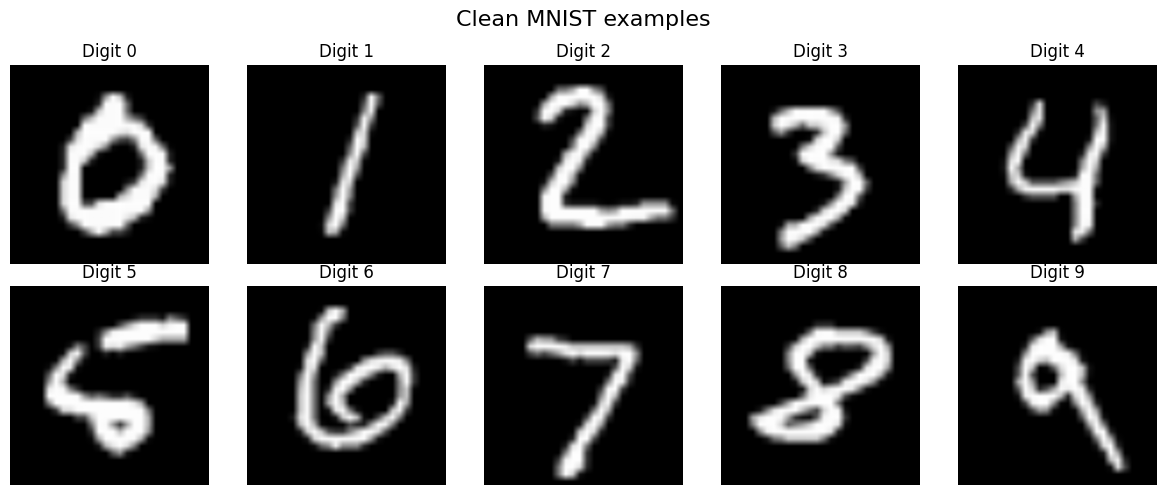

In [5]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5),
)

fig.suptitle("Clean MNIST examples", fontsize=16)

for idx, class_id in enumerate(ig_classes):
    row, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id, to_device=False)

    plot_image(
        axes[row, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {ig_experiment_vis.class_names[class_id]}",
        cmap="gray",
    )

plt.tight_layout()
plt.show()

## IG dla niezaatakowanych danych

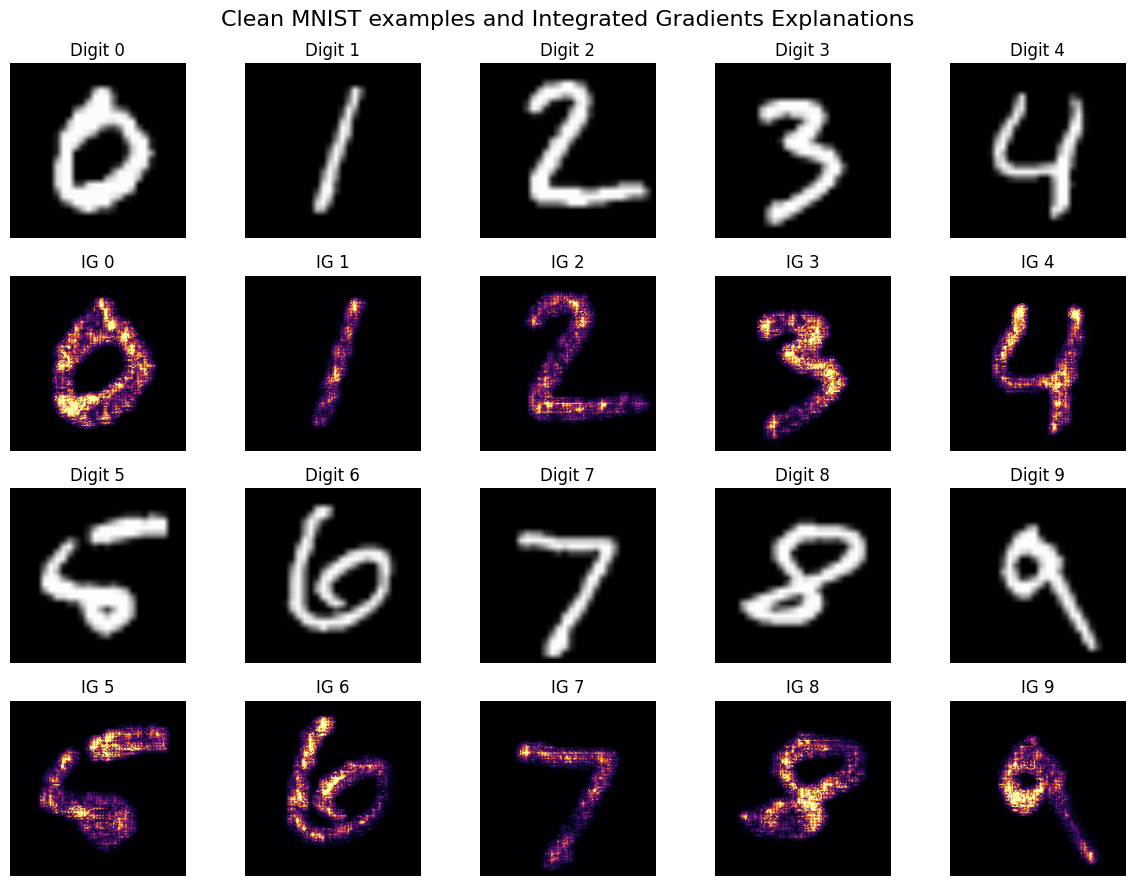

In [6]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    "Clean MNIST examples and Integrated Gradients Explanations",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id)
    clean_img = tensor_to_img(clean_tensor)

    attr_ig = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        clean_img,
        title=f"Digit {class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_ig,
        title=f"IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

plt.tight_layout()
plt.show()

## Atak FGSM - prezentacja

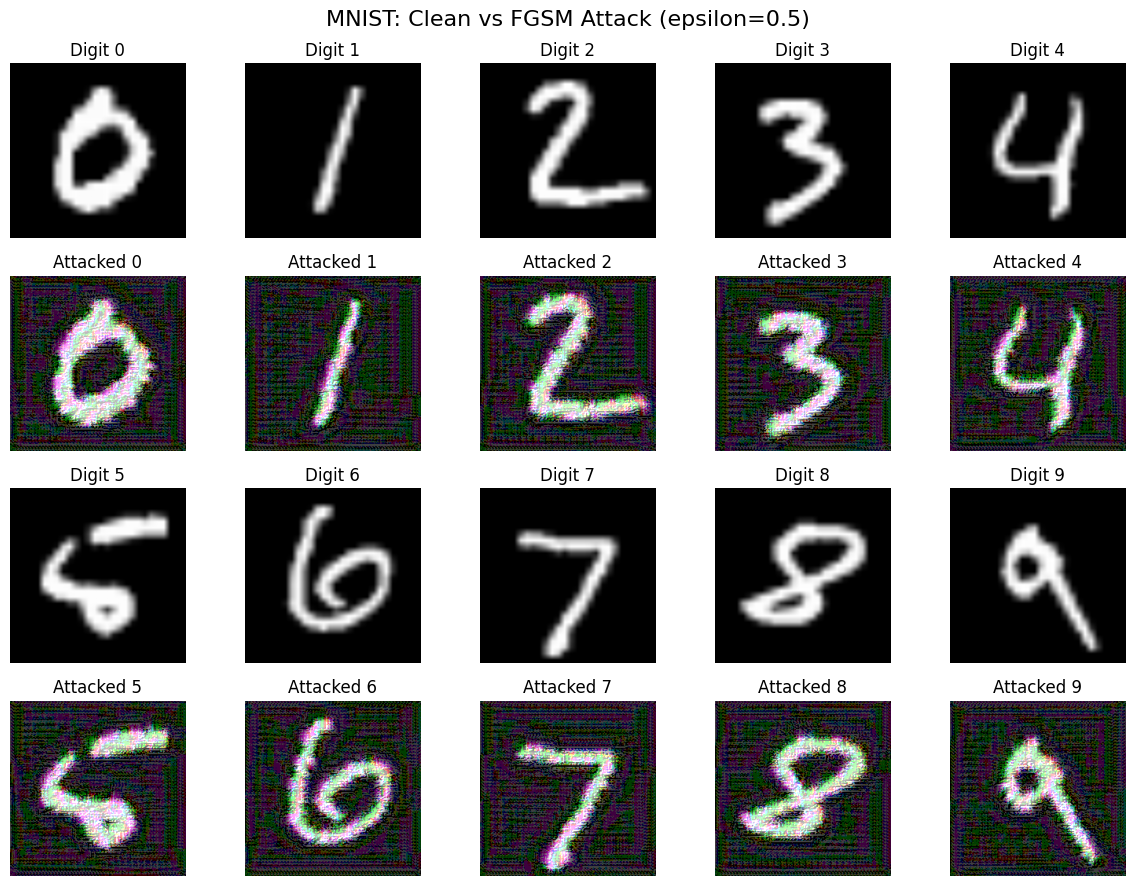

In [7]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: Clean vs FGSM Attack (epsilon={epsilon})",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(
        class_id,
        to_device=False,
    )

    noised_tensor = perturbations.fgsm(
        input_tensor=clean_tensor,
        target_class=class_id,
        epsilon=epsilon,
    )

    plot_image(
        axes[block * 2, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        tensor_to_img(noised_tensor),
        title=f"Attacked {class_names[class_id]}",
        cmap="gray",
    )

plt.tight_layout()
plt.show()

## IG danych niezaatakowanych oraz zaatakowanych

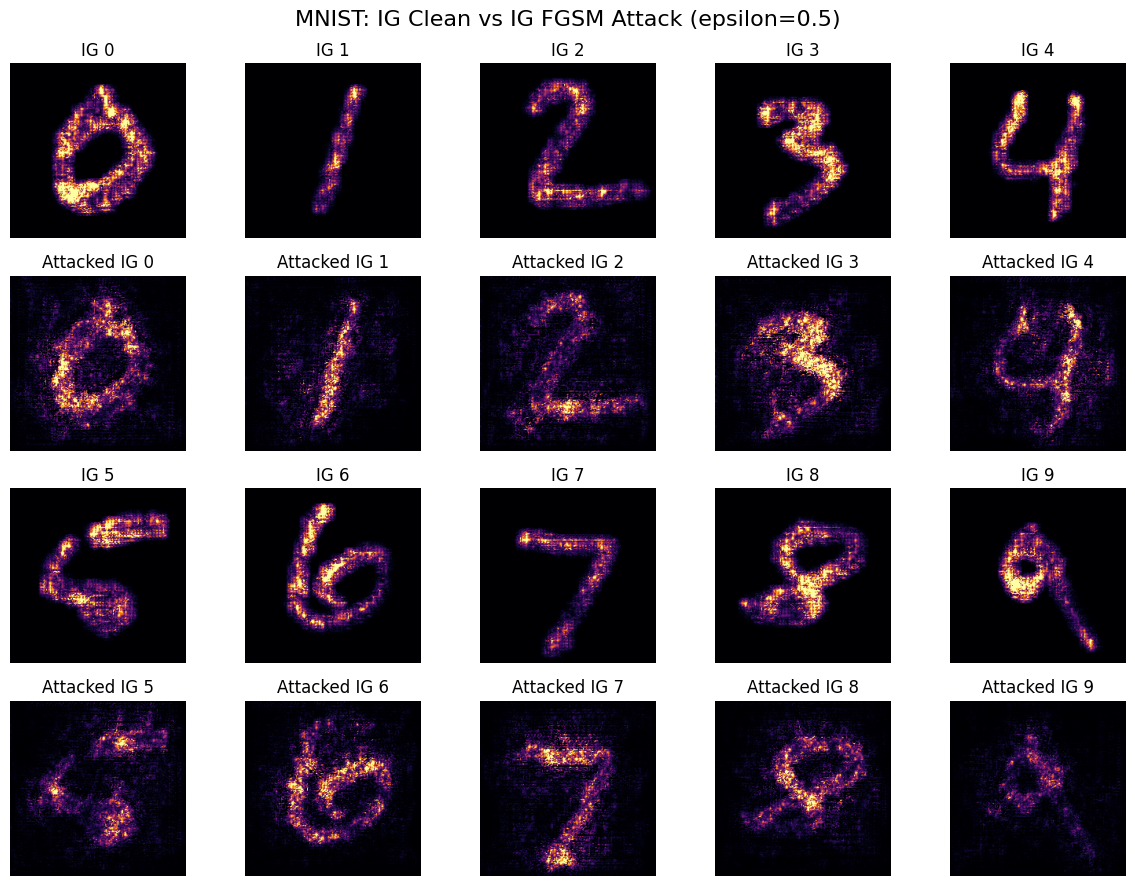

In [8]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: IG Clean vs IG FGSM Attack (epsilon={epsilon})",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment_vis.get_clean_tensor(class_id)

    noised_tensor = ig_experiment_vis.perturbations.fgsm(
        input_tensor=clean_tensor,
        target_class=class_id,
        epsilon=epsilon,
    )

    clean_attr = ig_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    noised_attr = ig_experiment_vis.explainer.explain(
        input_tensor=noised_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        clean_attr,
        title=f"IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

    plot_image(
        axes[block * 2 + 1, col],
        noised_attr,
        title=f"Attacked IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

plt.tight_layout()
plt.show()

## Cosine Similarity oraz TopK IoU (IG)

In [9]:
df_similarity = ig_experiment.run_similarity_metrics(
    perturbation_type="fgsm",
    values=config.ExperimentConfig().fgsm_epsilons,
)

display(
    ig_experiment.make_pivot(
        df_similarity,
        "CosineSimilarity",
    ).round(3)
)

display(
    ig_experiment.make_pivot(
        df_similarity,
        "TopK_IoU",
    ).round(3)
)

display(ig_experiment.summarize_similarity(df_similarity).round(3))

Processing fgsm=0.01
Processing fgsm=0.03
Processing fgsm=0.05
Processing fgsm=0.075
Processing fgsm=0.1
Processing fgsm=0.15
Processing fgsm=0.2
Processing fgsm=0.3
Processing fgsm=0.4
Processing fgsm=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,0.914,0.915,0.918,0.915,0.923,0.918,0.912,0.899,0.911,0.908
0.030,0.856,0.862,0.857,0.856,0.870,0.856,0.848,0.841,0.849,0.843
0.050,0.823,0.827,0.828,0.828,0.841,0.825,0.818,0.811,0.816,0.812
0.075,0.794,0.791,0.798,0.800,0.816,0.796,0.787,0.785,0.789,0.789
0.100,0.772,0.761,0.780,0.778,0.793,0.773,0.764,0.764,0.770,0.771
0.150,0.744,0.717,0.750,0.740,0.752,0.732,0.730,0.733,0.746,0.751
0.200,0.718,0.691,0.726,0.708,0.719,0.691,0.705,0.709,0.726,0.733
0.300,0.672,0.648,0.681,0.656,0.655,0.618,0.677,0.674,0.683,0.690
0.400,0.631,0.613,0.630,0.623,0.605,0.564,0.630,0.636,0.636,0.619


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,0.657,0.887,0.734,0.731,0.734,0.746,0.751,0.743,0.714,0.765
0.030,0.568,0.841,0.652,0.648,0.667,0.655,0.673,0.675,0.619,0.689
0.050,0.532,0.809,0.621,0.618,0.637,0.622,0.642,0.646,0.584,0.666
0.075,0.505,0.777,0.594,0.600,0.613,0.595,0.618,0.625,0.561,0.644
0.100,0.487,0.749,0.576,0.584,0.592,0.576,0.600,0.610,0.544,0.629
0.150,0.458,0.699,0.545,0.551,0.554,0.541,0.571,0.583,0.517,0.599
0.200,0.436,0.655,0.516,0.522,0.523,0.505,0.548,0.556,0.494,0.573
0.300,0.396,0.587,0.463,0.463,0.473,0.438,0.506,0.505,0.459,0.523
0.400,0.360,0.535,0.411,0.424,0.432,0.387,0.454,0.456,0.427,0.464


,Value,CosineMean,CosineStd,TopKIoUMean,TopKIoUStd
0,0.010,0.913,0.019,0.746,0.078
1,0.030,0.854,0.019,0.669,0.089
2,0.050,0.823,0.020,0.638,0.091
3,0.075,0.794,0.022,0.613,0.091
4,0.100,0.773,0.024,0.595,0.090
5,0.150,0.740,0.029,0.562,0.085
6,0.200,0.713,0.033,0.533,0.079
7,0.300,0.665,0.043,0.481,0.073
8,0.400,0.619,0.052,0.435,0.067
9,0.500,0.572,0.050,0.391,0.063


## Deletion AUC

In [10]:
df_deletion = ig_experiment.run_deletion_auc(
    perturbation_type="fgsm",
    values=config.ExperimentConfig().fgsm_epsilons,
)

display(
    ig_experiment.make_pivot(
        df_deletion,
        "DeletionAUC_Perturbed",
    ).round(3)
)

display(ig_experiment.summarize_deletion(df_deletion).round(3))

Processing fgsm=0.01
Processing fgsm=0.03
Processing fgsm=0.05
Processing fgsm=0.075
Processing fgsm=0.1
Processing fgsm=0.15
Processing fgsm=0.2
Processing fgsm=0.3
Processing fgsm=0.4
Processing fgsm=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,0.409,0.867,0.350,0.147,0.472,0.485,0.380,0.748,0.414,0.217
0.030,0.347,0.819,0.295,0.112,0.413,0.417,0.311,0.671,0.357,0.167
0.050,0.286,0.785,0.223,0.082,0.360,0.348,0.235,0.627,0.291,0.128
0.075,0.207,0.717,0.167,0.056,0.304,0.275,0.155,0.541,0.209,0.092
0.100,0.170,0.636,0.140,0.040,0.248,0.204,0.100,0.456,0.148,0.063
0.150,0.106,0.474,0.092,0.026,0.172,0.105,0.053,0.335,0.092,0.043
0.200,0.091,0.384,0.087,0.020,0.103,0.080,0.039,0.262,0.075,0.029
0.300,0.061,0.265,0.065,0.009,0.072,0.049,0.028,0.151,0.071,0.016
0.400,0.053,0.189,0.056,0.004,0.055,0.034,0.020,0.092,0.061,0.012


,Value,CleanAUCMean,CleanAUCStd,PerturbedAUCMean,PerturbedAUCStd,CleanTargetConfidenceMean,PerturbedTargetConfidenceMean,PredictionChanges
0,0.010,0.308,0.242,0.449,0.291,0.999,0.999,0
1,0.030,0.308,0.242,0.391,0.286,0.999,0.995,0
2,0.050,0.308,0.242,0.337,0.282,0.999,0.988,0
3,0.075,0.308,0.242,0.272,0.265,0.999,0.972,1
4,0.100,0.308,0.242,0.220,0.241,0.999,0.947,2
5,0.150,0.308,0.242,0.150,0.179,0.999,0.870,11
6,0.200,0.308,0.242,0.117,0.140,0.999,0.766,17
7,0.300,0.308,0.242,0.079,0.095,0.999,0.506,45
8,0.400,0.308,0.242,0.057,0.062,0.999,0.321,61
9,0.500,0.308,0.242,0.045,0.043,0.999,0.205,77


## Konfiguracja Occlusion

In [11]:
occ_explainer = OcclusionExplainer(
    model=model, device=device, config=config.OcclusionConfig(), dataset=dataset_name
)
occ_experiment = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples,
    explainer=occ_explainer,
    perturbations=perturbations,
)
occ_experiment_vis = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples_vis,
    explainer=occ_explainer,
    perturbations=perturbations,
)

occ_classes = occ_experiment_vis.selected_classes

all_occ_attrs = []
for class_id in occ_classes:
    clean_tensor = occ_experiment_vis.get_clean_tensor(class_id)
    noised_tensor = occ_experiment_vis.get_perturbed_tensor(
        clean_tensor=clean_tensor,
        class_id=class_id,
        perturbation_type="gaussian",
        value=epsilon,
    )

    clean_attr = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor, target_class=class_id
    )["raw"]

    noised_attr = occ_experiment_vis.explainer.explain(
        input_tensor=noised_tensor, target_class=class_id
    )["raw"]

    all_occ_attrs.append(clean_attr)
    all_occ_attrs.append(noised_attr)

occ_vmin = min(attr.min() for attr in all_occ_attrs)
occ_vmax = max(attr.max() for attr in all_occ_attrs)


## Occlusion dla niezatakowanych danych

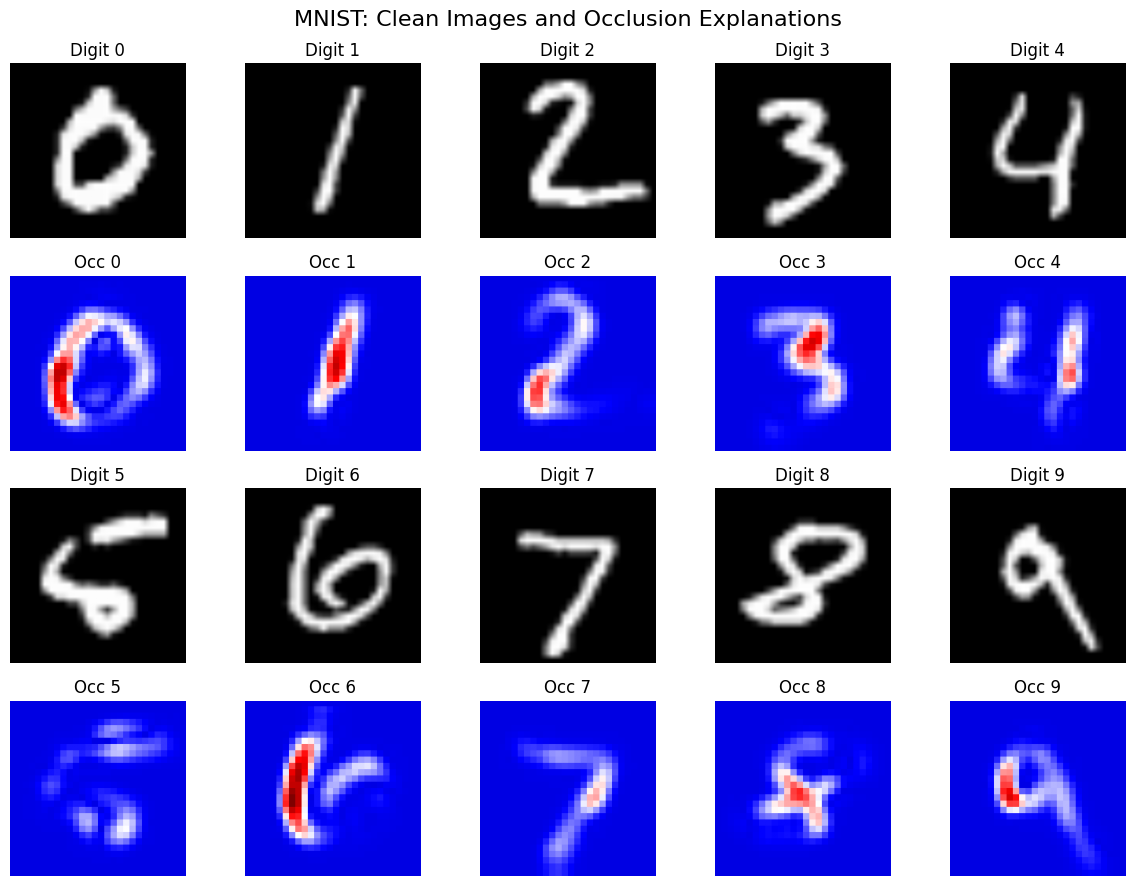

In [12]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    "MNIST: Clean Images and Occlusion Explanations",
    fontsize=16,
)

for idx, class_id in enumerate(occ_classes):
    block, col = divmod(idx, 5)

    clean_tensor = occ_experiment_vis.get_clean_tensor(class_id)

    attr_occ = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {occ_experiment_vis.class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_occ,
        title=f"Occ {occ_experiment_vis.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

plt.tight_layout()
plt.show()

## Occlusion danych niezaatakowanych oraz zaatakowanych

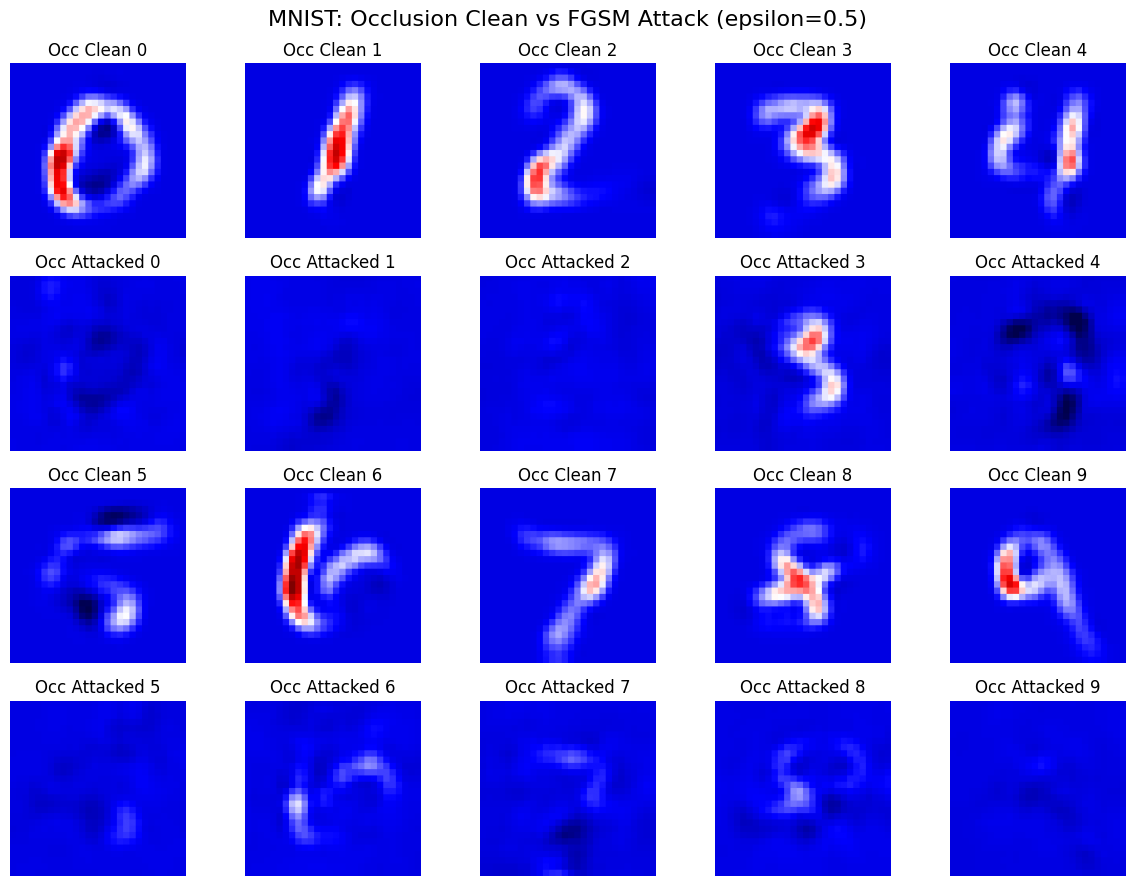

In [13]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: Occlusion Clean vs FGSM Attack (epsilon={epsilon})",
    fontsize=16,
)

for idx, class_id in enumerate(occ_classes):
    block, col = divmod(idx, 5)

    clean_tensor = occ_experiment_vis.get_clean_tensor(class_id)

    noised_tensor = occ_experiment_vis.perturbations.fgsm(
        input_tensor=clean_tensor,
        target_class=class_id,
        epsilon=epsilon,
    )

    attr_occ_clean = occ_experiment_vis.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["raw"]

    attr_occ_noised = occ_experiment_vis.explainer.explain(
        input_tensor=noised_tensor,
        target_class=class_id,
    )["raw"]

    plot_image(
        axes[block * 2, col],
        attr_occ_clean,
        title=f"Occ Clean {occ_experiment.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_occ_noised,
        title=f"Occ Attacked {occ_experiment.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

plt.tight_layout()
plt.show()

## Cosine Similarity oraz TopK IoU (Occlusion)

In [14]:
df_occ_similarity = occ_experiment.run_similarity_metrics(
    perturbation_type="fgsm",
    values=config.ExperimentConfig().fgsm_epsilons,
)

display(
    occ_experiment.make_pivot(
        df_occ_similarity,
        "CosineSimilarity",
    ).round(3)
)

display(
    occ_experiment.make_pivot(
        df_occ_similarity,
        "TopK_IoU",
    ).round(3)
)

display(occ_experiment.summarize_similarity(df_occ_similarity).round(3))

Processing fgsm=0.01
Processing fgsm=0.03
Processing fgsm=0.05
Processing fgsm=0.075
Processing fgsm=0.1
Processing fgsm=0.15
Processing fgsm=0.2
Processing fgsm=0.3
Processing fgsm=0.4
Processing fgsm=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,1.000,0.999,1.000,1.000,0.999,0.999,1.000,0.999,1.000,1.000
0.030,0.998,0.991,0.998,0.997,0.993,0.992,0.999,0.995,0.998,0.997
0.050,0.994,0.975,0.994,0.994,0.981,0.982,0.997,0.989,0.995,0.994
0.075,0.985,0.950,0.988,0.987,0.960,0.968,0.993,0.978,0.989,0.987
0.100,0.973,0.928,0.979,0.978,0.937,0.950,0.987,0.965,0.981,0.978
0.150,0.942,0.873,0.946,0.956,0.888,0.913,0.971,0.927,0.959,0.950
0.200,0.904,0.803,0.902,0.931,0.835,0.879,0.945,0.871,0.928,0.905
0.300,0.803,0.694,0.818,0.888,0.739,0.813,0.870,0.760,0.850,0.800
0.400,0.688,0.629,0.750,0.831,0.669,0.747,0.778,0.663,0.764,0.703


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,0.965,0.962,0.969,0.965,0.968,0.951,0.980,0.956,0.978,0.973
0.030,0.931,0.899,0.938,0.921,0.914,0.880,0.960,0.916,0.955,0.941
0.050,0.890,0.860,0.909,0.888,0.863,0.823,0.945,0.872,0.926,0.897
0.075,0.843,0.805,0.864,0.857,0.785,0.753,0.930,0.806,0.876,0.852
0.100,0.791,0.760,0.834,0.826,0.726,0.713,0.889,0.757,0.831,0.803
0.150,0.696,0.671,0.745,0.777,0.613,0.651,0.808,0.647,0.757,0.716
0.200,0.610,0.595,0.672,0.729,0.537,0.587,0.727,0.570,0.680,0.615
0.300,0.445,0.469,0.512,0.644,0.434,0.500,0.558,0.405,0.533,0.475
0.400,0.338,0.414,0.419,0.543,0.352,0.416,0.446,0.315,0.431,0.373


,Value,CosineMean,CosineStd,TopKIoUMean,TopKIoUStd
0,0.010,0.999,0.001,0.967,0.025
1,0.030,0.996,0.006,0.926,0.054
2,0.050,0.989,0.017,0.887,0.078
3,0.075,0.978,0.034,0.837,0.105
4,0.100,0.966,0.046,0.793,0.124
5,0.150,0.933,0.068,0.708,0.147
6,0.200,0.890,0.094,0.632,0.160
7,0.300,0.804,0.125,0.497,0.165
8,0.400,0.722,0.139,0.405,0.168
9,0.500,0.658,0.134,0.332,0.157


## Deletion AUC (Occlusion)

In [15]:
df_occ_deletion = occ_experiment.run_deletion_auc(
    perturbation_type="fgsm",
    values=config.ExperimentConfig().fgsm_epsilons,
)

display(
    occ_experiment.make_pivot(
        df_occ_deletion,
        "DeletionAUC_Perturbed",
    ).round(3)
)

display(occ_experiment.summarize_deletion(df_occ_deletion).round(3))

Processing fgsm=0.01
Processing fgsm=0.03
Processing fgsm=0.05
Processing fgsm=0.075
Processing fgsm=0.1
Processing fgsm=0.15
Processing fgsm=0.2
Processing fgsm=0.3
Processing fgsm=0.4
Processing fgsm=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.010,0.104,0.974,0.113,0.066,0.092,0.178,0.080,0.148,0.093,0.053
0.030,0.091,0.965,0.110,0.061,0.083,0.183,0.076,0.142,0.087,0.047
0.050,0.086,0.949,0.096,0.056,0.077,0.177,0.071,0.132,0.091,0.042
0.075,0.076,0.886,0.086,0.051,0.074,0.197,0.064,0.120,0.085,0.035
0.100,0.069,0.868,0.090,0.045,0.071,0.187,0.057,0.109,0.077,0.033
0.150,0.065,0.793,0.053,0.032,0.062,0.142,0.051,0.089,0.064,0.027
0.200,0.070,0.679,0.050,0.022,0.064,0.106,0.047,0.072,0.058,0.023
0.300,0.058,0.449,0.038,0.010,0.105,0.052,0.035,0.067,0.050,0.014
0.400,0.056,0.252,0.026,0.004,0.114,0.071,0.025,0.074,0.037,0.011


,Value,CleanAUCMean,CleanAUCStd,PerturbedAUCMean,PerturbedAUCStd,CleanTargetConfidenceMean,PerturbedTargetConfidenceMean,PredictionChanges
0,0.010,0.194,0.27,0.190,0.269,0.999,0.999,0
1,0.030,0.194,0.27,0.184,0.269,0.999,0.995,0
2,0.050,0.194,0.27,0.178,0.266,0.999,0.988,0
3,0.075,0.194,0.27,0.167,0.257,0.999,0.972,1
4,0.100,0.194,0.27,0.161,0.256,0.999,0.947,2
5,0.150,0.194,0.27,0.138,0.241,0.999,0.870,11
6,0.200,0.194,0.27,0.119,0.217,0.999,0.766,17
7,0.300,0.194,0.27,0.088,0.155,0.999,0.506,45
8,0.400,0.194,0.27,0.067,0.093,0.999,0.321,61
9,0.500,0.194,0.27,0.062,0.083,0.999,0.205,77
